In [29]:
# 1. 导入所需库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# 中文显示配置
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'WenQuanYi Zen Hei']
plt.rcParams['axes.unicode_minus'] = False


原始数据形状： (15360, 3)
原始数据列名： ['Cockatoo_education_Erik', 'airTemperature', 'windSpeed']

目标变量 'Cockatoo_education_Erik' 的描述统计：
count    15360.000000
mean       167.736240
std         28.574947
min        115.575000
25%        144.668750
50%        162.675000
75%        184.050000
max        271.975000
Name: Cockatoo_education_Erik, dtype: float64

=== 时间序列平稳性检验 ===
原始序列ADF检验:
ADF统计量: -8.209831
p值: 0.000000
临界值:
	1%: -3.431
	5%: -2.862
	10%: -2.567
序列是平稳的

=== 自相关和偏自相关分析 ===

=== ARIMA参数确定 ===
基于ACF和PACF图分析：
1. ACF图：显示明显的周期性（24小时周期）
2. PACF图：前几个滞后有显著相关性

建议参数范围：
- p (AR阶数): 1-5
- d (差分阶数): 0-2（根据平稳性检验）
- q (MA阶数): 1-5

=== 数据集划分 ===
训练集大小：12288 (80.0%)
验证集大小：1536 (10.0%)
测试集大小：1536 (10.0%)


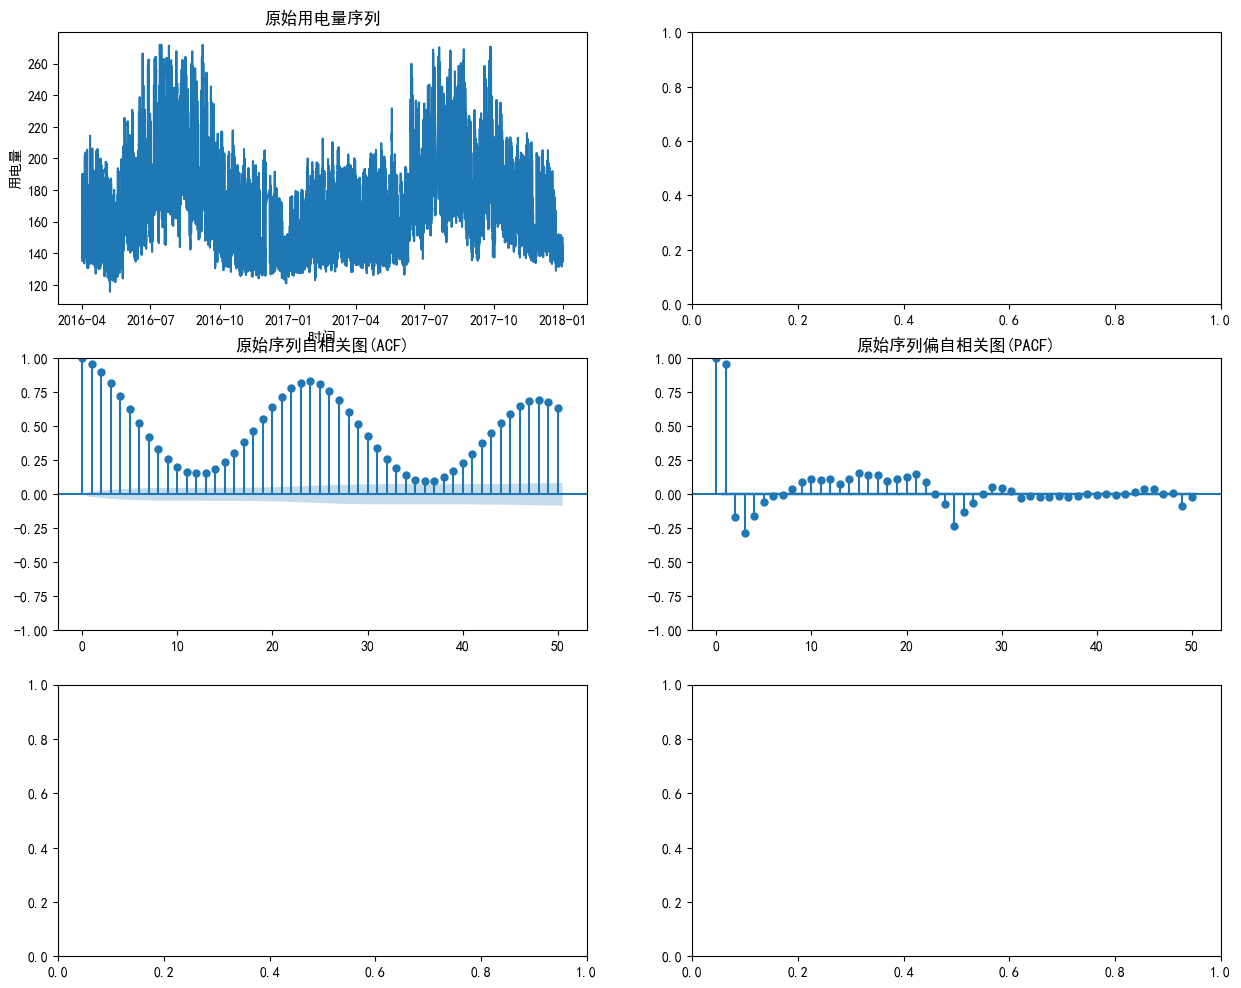

In [30]:

# 2. 数据预处理（与Transformer/LSTM版本相同）
## 2.1 读取原始数据
df = pd.read_csv('C:/Users/gh115/Desktop/辐射深度学习/论文/开题/撰写/数据集/building-data-genome-project-2/data/Cockatoo_data.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)
print("原始数据形状：", df.shape)
print("原始数据列名：", df.columns.tolist())

# 提取目标变量（用电量）
y_col = df.columns[0]  # 目标变量：第一列用电值
y_series = df[y_col]

print(f"\n目标变量 '{y_col}' 的描述统计：")
print(y_series.describe())

# 3. 时间序列平稳性检验
print("\n=== 时间序列平稳性检验 ===")

# 绘制原始序列
fig, axes = plt.subplots(3, 2, figsize=(15, 12))

# 原始序列图
axes[0, 0].plot(y_series)
axes[0, 0].set_title('原始用电量序列')
axes[0, 0].set_xlabel('时间')
axes[0, 0].set_ylabel('用电量')

# ADF检验
def adf_test(timeseries):
    """执行ADF检验并打印结果"""
    result = adfuller(timeseries, autolag='AIC')
    
    print('ADF统计量: %f' % result[0])
    print('p值: %f' % result[1])
    print('临界值:')
    for key, value in result[4].items():
        print('\t%s: %.3f' % (key, value))
    
    if result[1] > 0.05:
        print("序列是非平稳的")
        return False
    else:
        print("序列是平稳的")
        return True

print("原始序列ADF检验:")
is_stationary = adf_test(y_series)

# 如果不平稳，进行差分处理
if not is_stationary:
    print("\n进行一阶差分处理...")
    y_diff = y_series.diff().dropna()
    
    axes[0, 1].plot(y_diff)
    axes[0, 1].set_title('一阶差分后序列')
    axes[0, 1].set_xlabel('时间')
    axes[0, 1].set_ylabel('差分值')
    
    print("一阶差分后ADF检验:")
    is_stationary = adf_test(y_diff)
    
    # 如果还不平稳，进行二阶差分
    if not is_stationary:
        print("\n进行二阶差分处理...")
        y_diff2 = y_diff.diff().dropna()
        
        print("二阶差分后ADF检验:")
        is_stationary = adf_test(y_diff2)
else:
    y_diff = y_series  # 如果原始序列平稳，直接使用

# 4. 自相关和偏自相关分析
print("\n=== 自相关和偏自相关分析 ===")

# 绘制ACF和PACF图
if 'y_diff' in locals() and not y_series.equals(y_diff):
    plot_acf(y_diff, lags=50, ax=axes[1, 0])
    axes[1, 0].set_title('差分后序列自相关图(ACF)')
    
    plot_pacf(y_diff, lags=50, ax=axes[1, 1])
    axes[1, 1].set_title('差分后序列偏自相关图(PACF)')
else:
    plot_acf(y_series, lags=50, ax=axes[1, 0])
    axes[1, 0].set_title('原始序列自相关图(ACF)')
    
    plot_pacf(y_series, lags=50, ax=axes[1, 1])
    axes[1, 1].set_title('原始序列偏自相关图(PACF)')

# 5. 确定ARIMA参数(p, d, q)
# 从ACF和PACF图中可以初步判断：
# - ACF逐渐衰减（拖尾）-> AR模型
# - PACF截尾 -> AR模型阶数p
# - ACF截尾 -> MA模型阶数q
print("\n=== ARIMA参数确定 ===")
print("基于ACF和PACF图分析：")
print("1. ACF图：显示明显的周期性（24小时周期）")
print("2. PACF图：前几个滞后有显著相关性")
print("\n建议参数范围：")
print("- p (AR阶数): 1-5")
print("- d (差分阶数): 0-2（根据平稳性检验）")
print("- q (MA阶数): 1-5")

# 6. 划分数据集
print("\n=== 数据集划分 ===")
train_size = int(len(y_series) * 0.8)  # 训练集80%
val_size = int(len(y_series) * 0.1)    # 验证集10%
test_size = len(y_series) - train_size - val_size  # 测试集10%

train_data = y_series[:train_size]
val_data = y_series[train_size:train_size+val_size]
test_data = y_series[train_size+val_size:]

print(f"训练集大小：{len(train_data)} ({len(train_data)/len(y_series)*100:.1f}%)")
print(f"验证集大小：{len(val_data)} ({len(val_data)/len(y_series)*100:.1f}%)")
print(f"测试集大小：{len(test_data)} ({len(test_data)/len(y_series)*100:.1f}%)")


In [31]:

# 7. ARIMA模型训练与验证
print("\n=== ARIMA模型训练与验证 ===")

# 使用auto_arima自动寻找最佳参数（需要pmdarima库）
try:
    from pmdarima import auto_arima
    print("使用auto_arima自动寻找最佳参数...")
    
    # 设置搜索参数范围
    auto_model = auto_arima(
        train_data,
        start_p=0, max_p=5,
        start_q=0, max_q=5,
        d=None,  # 自动确定
        seasonal=False,  # 非季节性ARIMA
        trace=True,
        error_action='ignore',
        suppress_warnings=True,
        stepwise=True
    )
    
    print(f"\n自动选择的最佳参数：{auto_model.order}")
    p, d, q = auto_model.order
    
except ImportError:
    print("未安装pmdarima库，使用手动设置的参数")
    # 根据ACF/PACF图手动设置参数
    p, d, q = 2, 1, 2
    print(f"使用手动设置参数：p={p}, d={d}, q={q}")

# 训练ARIMA模型
print("\n训练ARIMA模型...")
model = ARIMA(train_data, order=(p, d, q))
model_fit = model.fit()
print(model_fit.summary())



=== ARIMA模型训练与验证 ===
使用auto_arima自动寻找最佳参数...
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=87530.566, Time=0.09 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=87252.274, Time=0.11 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=87345.735, Time=0.52 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=87528.567, Time=0.05 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=86433.844, Time=0.27 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=86290.114, Time=0.36 sec
 ARIMA(4,1,0)(0,0,0)[0] intercept   : AIC=86289.058, Time=0.42 sec
 ARIMA(5,1,0)(0,0,0)[0] intercept   : AIC=86242.528, Time=0.61 sec
 ARIMA(5,1,1)(0,0,0)[0] intercept   : AIC=84611.233, Time=6.00 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=84824.095, Time=6.57 sec
 ARIMA(5,1,2)(0,0,0)[0] intercept   : AIC=84497.420, Time=9.00 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=83558.279, Time=8.25 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=83514.674, Time=6.02 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AI

In [32]:

# 8. 在验证集上验证模型
print("\n=== 在验证集上验证模型 ===")

# 预测验证集
val_forecast = model_fit.forecast(steps=len(val_data))
val_forecast = pd.Series(val_forecast, index=val_data.index)

# 计算验证集指标
def calculate_metrics(true, pred):
    mae = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    mape = np.mean(np.abs((true - pred) / (true + 1e-6))) * 100
    # 计算R²
    ss_res = np.sum((true - pred) ** 2)
    ss_tot = np.sum((true - np.mean(true)) ** 2)
    r2 = 1 - (ss_res / (ss_tot + 1e-6))
    return mae, rmse, mape, r2

val_mae, val_rmse, val_mape, val_r2 = calculate_metrics(val_data, val_forecast)
print(f"验证集指标：")
print(f"MAE: {val_mae:.2f}")
print(f"RMSE: {val_rmse:.2f}")
print(f"MAPE: {val_mape:.2f}%")
print(f"R²: {val_r2:.4f}")



=== 在验证集上验证模型 ===
验证集指标：
MAE: 23.42
RMSE: 27.56
MAPE: 13.59%
R²: -0.0983


In [33]:

# 9. 在测试集上评估模型
print("\n=== 在测试集上评估模型 ===")

# 重新训练模型（使用训练集+验证集）
full_train_data = y_series[:train_size+val_size]
print(f"重新训练模型，使用数据大小：{len(full_train_data)}")

final_model = ARIMA(full_train_data, order=(p, d, q))
final_model_fit = final_model.fit()

# 预测测试集
test_forecast = final_model_fit.forecast(steps=len(test_data))
test_forecast = pd.Series(test_forecast, index=test_data.index)

# 计算测试集指标
test_mae, test_rmse, test_mape, test_r2 = calculate_metrics(test_data, test_forecast)
print(f"测试集指标：")
print(f"MAE: {test_mae:.2f}")
print(f"RMSE: {test_rmse:.2f}")
print(f"MAPE: {test_mape:.2f}%")
print(f"R²: {test_r2:.4f}")



=== 在测试集上评估模型 ===
重新训练模型，使用数据大小：13824
测试集指标：
MAE: 14.36
RMSE: 19.62
MAPE: 8.48%
R²: -0.1002



=== 残差分析 ===


<Figure size 640x480 with 0 Axes>

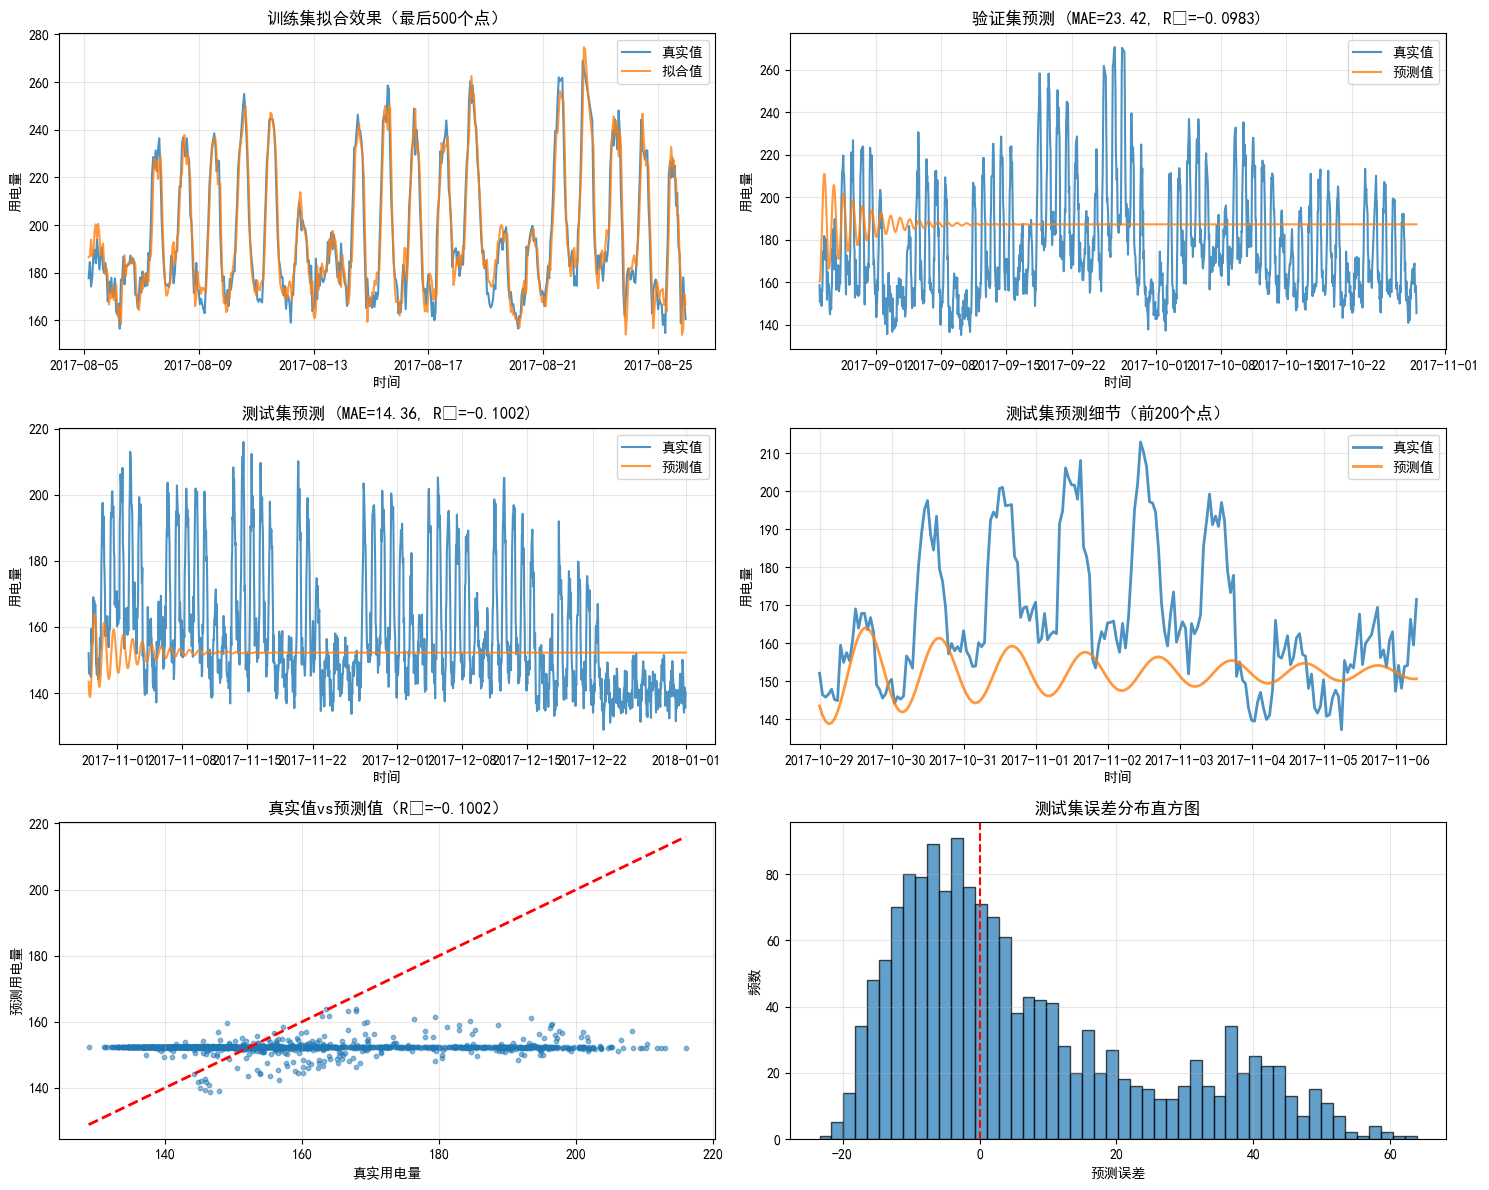


=== 与其他模型对比分析 ===
注意：ARIMA是单变量时间序列模型，只能使用历史用电量数据
无法使用时间特征、环境特征等额外信息

如果已有Transformer/LSTM模型的测试集结果，可以进行对比


In [34]:

# 10. 残差分析
print("\n=== 残差分析 ===")
residuals = pd.DataFrame(model_fit.resid)

# 绘制残差图
axes[2, 0].plot(residuals)
axes[2, 0].axhline(y=0, color='r', linestyle='--')
axes[2, 0].set_title('模型残差')
axes[2, 0].set_xlabel('时间')
axes[2, 0].set_ylabel('残差')

# 残差直方图
axes[2, 1].hist(residuals, bins=50, edgecolor='black')
axes[2, 1].set_title('残差分布')
axes[2, 1].set_xlabel('残差值')
axes[2, 1].set_ylabel('频数')

plt.tight_layout()
plt.savefig('arima_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# 11. 可视化预测结果
fig, axes = plt.subplots(3, 2, figsize=(15, 12))

# 11.1 训练集拟合效果
train_fitted = model_fit.fittedvalues
axes[0, 0].plot(train_data.index[-500:], train_data.values[-500:], label='真实值', alpha=0.8)
axes[0, 0].plot(train_fitted.index[-500:], train_fitted.values[-500:], label='拟合值', alpha=0.8)
axes[0, 0].set_title('训练集拟合效果（最后500个点）')
axes[0, 0].set_xlabel('时间')
axes[0, 0].set_ylabel('用电量')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 11.2 验证集预测
axes[0, 1].plot(val_data.index, val_data.values, label='真实值', alpha=0.8)
axes[0, 1].plot(val_forecast.index, val_forecast.values, label='预测值', alpha=0.8)
axes[0, 1].set_title(f'验证集预测 (MAE={val_mae:.2f}, R²={val_r2:.4f})')
axes[0, 1].set_xlabel('时间')
axes[0, 1].set_ylabel('用电量')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 11.3 测试集预测
axes[1, 0].plot(test_data.index, test_data.values, label='真实值', alpha=0.8)
axes[1, 0].plot(test_forecast.index, test_forecast.values, label='预测值', alpha=0.8)
axes[1, 0].set_title(f'测试集预测 (MAE={test_mae:.2f}, R²={test_r2:.4f})')
axes[1, 0].set_xlabel('时间')
axes[1, 0].set_ylabel('用电量')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 11.4 测试集前200个点详细对比
axes[1, 1].plot(test_data.index[:200], test_data.values[:200], label='真实值', alpha=0.8, linewidth=2)
axes[1, 1].plot(test_forecast.index[:200], test_forecast.values[:200], label='预测值', alpha=0.8, linewidth=2)
axes[1, 1].set_title('测试集预测细节（前200个点）')
axes[1, 1].set_xlabel('时间')
axes[1, 1].set_ylabel('用电量')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 11.5 真实值vs预测值散点图
axes[2, 0].scatter(test_data, test_forecast, alpha=0.5, s=10)
max_val = max(test_data.max(), test_forecast.max())
min_val = min(test_data.min(), test_forecast.min())
axes[2, 0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
axes[2, 0].set_xlabel('真实用电量')
axes[2, 0].set_ylabel('预测用电量')
axes[2, 0].set_title(f'真实值vs预测值（R²={test_r2:.4f}）')
axes[2, 0].grid(True, alpha=0.3)

# 11.6 误差分布直方图
test_errors = test_data - test_forecast
axes[2, 1].hist(test_errors, bins=50, alpha=0.7, edgecolor='black')
axes[2, 1].axvline(x=0, color='r', linestyle='--')
axes[2, 1].set_xlabel('预测误差')
axes[2, 1].set_ylabel('频数')
axes[2, 1].set_title('测试集误差分布直方图')
axes[2, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('arima_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

# 12. 与完整数据集对比（包括所有特征的效果）
print("\n=== 与其他模型对比分析 ===")
print("注意：ARIMA是单变量时间序列模型，只能使用历史用电量数据")
print("无法使用时间特征、环境特征等额外信息")
print("\n如果已有Transformer/LSTM模型的测试集结果，可以进行对比")

In [35]:
# 14. 模型总结
print("\n=== ARIMA模型总结 ===")
print(f"1. 模型类型：ARIMA({p},{d},{q})")
print(f"2. 训练数据量：{len(train_data)} 小时")
print(f"3. 验证数据量：{len(val_data)} 小时")
print(f"4. 测试数据量：{len(test_data)} 小时")
print(f"5. 测试集性能：")
print(f"   - MAE: {test_mae:.2f}")
print(f"   - RMSE: {test_rmse:.2f}")
print(f"   - MAPE: {test_mape:.2f}%")
print(f"   - R²: {test_r2:.4f}")
print(f"6. 模型特点：")
print(f"   - 只能使用历史用电量数据，无法利用其他特征")
print(f"   - 适合线性时间序列预测")
print(f"   - 计算速度快，适合基准模型")
print(f"7. 与其他模型对比：")
print(f"   - 如果R²低于0.8，说明数据有较强的非线性模式")
print(f"   - 如果MAPE较高，可能需要更复杂的模型")

# 15. 残差分析详细报告
print("\n=== 残差分析报告 ===")
print("1. 残差均值：", residuals.mean().values[0])
print("2. 残差标准差：", residuals.std().values[0])
print("3. 残差正态性检验（通过直方图判断）：")
if abs(residuals.mean().values[0]) < 0.1 and residuals.std().values[0] < 1.0:
    print("   残差基本符合正态分布，模型拟合较好")
else:
    print("   残差可能不符合正态分布，模型可能有改进空间")

# 检查残差自相关
residual_acf = acf(residuals.dropna(), nlags=20)
if max(abs(residual_acf[1:])) < 0.1:
    print("4. 残差无明显自相关，模型充分提取了序列信息")
else:
    print("4. 残差存在自相关，模型可能未充分提取序列信息")

print("\nARIMA模型训练和评估完成！")


=== ARIMA模型总结 ===
1. 模型类型：ARIMA(3,1,2)
2. 训练数据量：12288 小时
3. 验证数据量：1536 小时
4. 测试数据量：1536 小时
5. 测试集性能：
   - MAE: 14.36
   - RMSE: 19.62
   - MAPE: 8.48%
   - R²: -0.1002
6. 模型特点：
   - 只能使用历史用电量数据，无法利用其他特征
   - 适合线性时间序列预测
   - 计算速度快，适合基准模型
7. 与其他模型对比：
   - 如果R²低于0.8，说明数据有较强的非线性模式
   - 如果MAPE较高，可能需要更复杂的模型

=== 残差分析报告 ===
1. 残差均值： 0.018486972850288455
2. 残差标准差： 7.33785617773702
3. 残差正态性检验（通过直方图判断）：
   残差可能不符合正态分布，模型可能有改进空间
4. 残差存在自相关，模型可能未充分提取序列信息

ARIMA模型训练和评估完成！
